# NMC 电池 SOH 预测 — 全量数据 MLP 深度集成（为迁移到 LFP 做准备）

**为什么用这个算法**：你有几百块电池、要求"用满全部数据不丢弃"，还要迁移到 LFP。
神经网络（MLP）用小批量 SGD 训练，**每个 epoch 都过一遍全部样本**（复杂度 O(N)，几十万行也没问题），
天然满足数据完整性；它的"特征提取器 + 回归头"结构又支持"冻结特征提取器、只重训头"的迁移。

在此基础上，用两个技巧补回 GPR 的优点：
- **深度集成**（训 K 个 MLP）→ 均值作预测、跨模型标准差作**不确定度**，顺带提升精度；
- **置换重要性**（permutation importance）→ 得到类似 **ARD 的特征相关性**。

同时保留一个 **GBDT 基线**：表格数据上原始精度常更高、也用满全部数据，但**不支持冻结/微调式迁移**。
所以——**要迁移用 MLP 集成；只看 NMC 单任务精度看 GBDT。**

**输入**：`OCV (V)`, `R0 (Ohm)`, `R1 (Ohm)`, `tau1 (s)`, `R2 (Ohm)`, `tau2 (s)`
｜ **输出**：`SOH (%)`

---
### 本版相对原始 notebook 的改动（调试记录，便于对照）
1. **P0 修复**：补上 `permutation_importance` 的 import；`cell 18` 保存时把不存在的 `gb`
   改成实际训练出的 `xgb`；同时补上原本缺失的 `HAS_TORCH` 定义（torch 是无条件 import 的，直接置 `True`）。
2. **训练提速**：`batch_size` 256→4096，配合 `ReduceLROnPlateau` 学习率调度，`epochs`/`patience` 相应缩短——
   原配置在 CPU 上一次完整训练要几十小时，是"调参数没用"的头号原因，根源是训练根本没跑完。
3. **缩小网络容量 + 加正则**：`hidden` 从 `(256,128,64)` 降到 `(128,64,32)`，`dropout` 0.1→0.25，
   `weight_decay` 1e-4→3e-4，配合 BatchNorm + GELU，专门针对"train 好、test 差"的过拟合。
4. **诊断补全**：训练集 R²（欠拟合/过拟合判断）、loss 曲线、MLP 专属置换重要性（区别于 XGBoost 的重要性）、
   特征相关性矩阵、 噪声敏感度检查、误差最大样本定位（按电池 + 按 SOH 区间）、
   `GroupKFold` 5 折交叉验证（比单次切分更能反映真实泛化能力）。
5. **工况自动解析**：移除手工工况字典，直接从 `cell_id` 或 `source_file` 中解析
   `温度grad_SOC_DOD`，例如 `VTC6_003_25grad_70SOC_60DOD` → `25grad_70soc_60dod`。


In [3]:
import os
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# 1. 彻底锁定随机种子（保证实验可复现）
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# 2. 全局配置：绘图大小与计算设备选择
plt.rcParams["figure.figsize"] = (6, 4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HAS_TORCH = True  # torch 在上面是无条件 import 的，这里恒为 True，供 cell 18 保存逻辑判断

print(f"🚀 环境就绪 | PyTorch: {torch.__version__} | 训练设备: {device}")

🚀 环境就绪 | PyTorch: 2.13.0+cu126 | 训练设备: cuda


## 1. 配置

`DATA_ROOT` 指向包含各电池文件夹的根目录。电池文件夹名或内部数据文件名应包含工况，
例如 `VTC6_003_25grad_70SOC_60DOD`。`read_one_file()` 是**唯一需要按数据内容格式调整**的地方。

In [4]:
DATA_ROOT = r"C:\Users\huang\OneDrive\桌面\output_rc_soh_1_300_mixed_conditions_noSOC30DOD20_noSOC50DOD20"

TEMPERATURE_COL = "Temperature (°C)"
FEATURES = ["OCV (V)", "R0 (Ohm)", "R1 (Ohm)", "tau1 (s)", "R2 (Ohm)", "tau2 (s)",TEMPERATURE_COL]
TARGET   = "SOH (%)"
LOG_TAU_COLS = ["tau1 (s)", "tau2 (s)"]
USE_LOG_TAU  = False
# 温度解析
_NUMBER = r"-?\d+(?:\.\d+)?"

_TEMP_RE = re.compile(
    rf"(?P<value>{_NUMBER})\s*(?:grad|°c)",
    re.IGNORECASE
)

def parse_temperature_from_name(name):
    text = Path(str(name)).stem
    m = _TEMP_RE.search(text)
    return float(m.group("value")) if m else np.nan


TIME_RE = re.compile(r"(\d{8})_(\d{6})")
def parse_time_from_name(fname):
    m = TIME_RE.search(fname)
    return datetime.strptime(m.group(1)+m.group(2), "%Y%m%d%H%M%S") if m else None

def read_one_file(fpath):
    '''把单个循环文件读成 DataFrame。请按你的真实文件格式修改这里。
       返回的 DataFrame 至少要含 FEATURES + [TARGET] 这些列。'''
    return pd.read_csv(fpath, sep=None, engine="python")

## 2. 遍历所有电池文件夹并合并

找不到 `DATA_ROOT` 时用**多电池合成数据**（默认 300 块）演示，模拟你的规模。

In [5]:
def load_all_batteries(root):
    root = Path(root); frames = []
    for cell_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        cell_id = cell_dir.name
        files = sorted((f for f in cell_dir.iterdir() if f.is_file()),
                       key=lambda f: (parse_time_from_name(f.name) or datetime.min))
        for order, f in enumerate(files):
            try:
                d = read_one_file(f).copy()
            except Exception as e:
                print("跳过", f.name, "->", e); continue
            d["cell_id"], d["file_time"], d["file_order"], d["source_file"] = \
                cell_id, parse_time_from_name(f.name), order, f.name
            temperature = parse_temperature_from_name(f.name)

            # 如果内部文件名没有温度，则从电池文件夹名读取
            if pd.isna(temperature):
                temperature = parse_temperature_from_name(cell_id)

            d[TEMPERATURE_COL] = temperature

            frames.append(d)
    if not frames:
        raise RuntimeError("没读到任何文件, 请检查 DATA_ROOT 和 read_one_file()")
    return pd.concat(frames, ignore_index=True)

df = load_all_batteries(DATA_ROOT)

if df[TEMPERATURE_COL].isna().any():
    missing_files = (
        df.loc[df[TEMPERATURE_COL].isna(), ["cell_id", "source_file"]]
        .drop_duplicates()
    )
    raise ValueError(
        "以下文件无法解析温度，请检查是否包含类似 25grad 的字段：\n"
        + missing_files.to_string(index=False)
    )


print("总样本 N =", len(df), " 电池数 =", df["cell_id"].nunique())
df.head()

总样本 N = 754982  电池数 = 200


,﻿segment_id,SOH (%),OCV (V),R0 (Ohm),R1 (Ohm),tau1 (s),R2 (Ohm),tau2 (s),cell_id,file_time,file_order,source_file,Temperature (°C)
0,1,"96,1","4,11152","0,023761","0,021848","27,7","0,015772","223,85",VTC6_003_25grad_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...,25.0
1,2,"96,0807","4,1111","0,024373","0,021893","28,47","0,015407","222,14",VTC6_003_25grad_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...,25.0
2,3,"96,0614","4,111268","0,024156","0,021858","27,57","0,015542","217,0",VTC6_003_25grad_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...,25.0
3,4,"96,0421","4,111116","0,024298","0,021961","28,0","0,015399","220,12",VTC6_003_25grad_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...,25.0
4,5,"96,0228","4,111059","0,024553","0,021858","28,78","0,015212","223,46",VTC6_003_25grad_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...,25.0


## 3. 预处理 + 按工况划分（每种工况都留 1 块电池进训练集）

- tau 做 log 变换；`StandardScaler` **只在训练集 fit**。
- **划分规则（本版新增）**：指定某个工况作测试集时，该工况仍会挑 `N_DONOR` 块电池
  **强制放进训练集**，其余电池才进测试集 —— 让模型对每种工况都"见过一点"，
  但被测的那些电池自身依然完全没被训练过。
- 其余工况的电池进训练池，再按 `cell_id` 分组抽 20% 做验证集。
- **同一块电池只会出现在 train / val / test 之一**，代码里有 assert 强制校验。
- **不做任何子采样**——全部样本都进入训练。
- 批量跑完所有工况见最后的 **第 9 节**。

In [6]:
# ==================== 1. 数据清洗与数值类型强制转换 ====================
all_numeric_cols = list(dict.fromkeys(
    FEATURES + [TARGET] + list(LOG_TAU_COLS)
))

for col in all_numeric_cols:
    if col not in df.columns:
        raise KeyError(f"数据中缺少列：{col}")

    # 统一清洗字符串并转换为数值
    cleaned = (
        df[col]
        .astype("string")
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    df[col] = pd.to_numeric(cleaned, errors="coerce")

# 检查哪些原始内容未能转换为数字
invalid_counts = df[all_numeric_cols].isna().sum()
invalid_counts = invalid_counts[invalid_counts > 0]

if not invalid_counts.empty:
    print("⚠️ 以下数值列存在空值或无法解析的内容：")
    print(invalid_counts.sort_values(ascending=False))

# 剔除模型所需列存在空值的样本
required_cols = list(dict.fromkeys(FEATURES + [TARGET] + list(LOG_TAU_COLS)))
data = df.dropna(subset=required_cols).copy().reset_index(drop=True)

# ==================== 2. 特征工程：标准对数变换（只对 tau 做 log） ====================
USE_LOG_TAU = True
if USE_LOG_TAU:
    for c in LOG_TAU_COLS:
        data[c] = np.log(data[c])

# 转换为模型所需的张量格式（仅保留原始 6 个特征）
X = data[FEATURES].values.astype(np.float32)
y = data[TARGET].values.astype(np.float32)
groups = data["cell_id"].values

# ==================== 3. 从文件名自动解析工况 ====================
# 支持示例：VTC6_003_25grad_70SOC_60DOD（大小写不敏感）；
# 也兼容 SOC70 / DOD60 这种数值写在标签后的形式。
_NUMBER = r"-?\d+(?:\.\d+)?"

# 不考虑温度工况
# _TEMP_RE = re.compile(rf"(?P<value>{_NUMBER})\s*(?:grad|°c)", re.IGNORECASE)
_SOC_RE = re.compile(rf"(?:(?P<before>{_NUMBER})\s*SOC|SOC\s*(?P<after>{_NUMBER}))", re.IGNORECASE)
_DOD_RE = re.compile(rf"(?:(?P<before>{_NUMBER})\s*DOD|DOD\s*(?P<after>{_NUMBER}))", re.IGNORECASE)

def _clean_number(token):
    value = float(token)
    return str(int(value)) if value.is_integer() else f"{value:g}"

def parse_condition_from_name(name):
    """从文件/文件夹名提取工况，返回如 25grad_70soc_60dod；无法解析则返回 None。"""
    text = Path(str(name)).stem
    # 不考虑温度
    # temp_m, soc_m, dod_m = _TEMP_RE.search(text), _SOC_RE.search(text), _DOD_RE.search(text)
    soc_m, dod_m = _SOC_RE.search(text), _DOD_RE.search(text)
    # if not (temp_m and soc_m and dod_m):
    if not (soc_m and dod_m):

        return None
    # temp = _clean_number(temp_m.group("value"))
    soc = _clean_number(soc_m.group("before") or soc_m.group("after"))
    dod = _clean_number(dod_m.group("before") or dod_m.group("after"))
    return f"{soc}soc_{dod}dod"

# 优先从电池文件夹名（cell_id）解析；若工况写在内部数据文件名，则回退到 source_file。
row_conditions = data["cell_id"].map(parse_condition_from_name)
if "source_file" in data.columns:
    row_conditions = row_conditions.fillna(data["source_file"].map(parse_condition_from_name))
data["condition"] = row_conditions

# 同一块电池必须只对应一个工况，否则按电池分组划分会产生歧义。
condition_counts = data.dropna(subset=["condition"]).groupby("cell_id")["condition"].nunique()
ambiguous_cells = condition_counts[condition_counts > 1]
if not ambiguous_cells.empty:
    details = (data[data["cell_id"].isin(ambiguous_cells.index)]
               .groupby("cell_id")["condition"].agg(lambda s: sorted(s.dropna().unique())))
    raise ValueError(f"同一块电池解析出了多个工况，请检查命名：\n{details.to_string()}")

cell_condition = (data.dropna(subset=["condition"])[["cell_id", "condition"]]
                  .drop_duplicates().set_index("cell_id")["condition"].to_dict())
available_cells = set(groups)
CELL2COND = {cell: cell_condition[cell] for cell in available_cells if cell in cell_condition}
COND_CELLS = {}
for _cell, _cond in CELL2COND.items():
    COND_CELLS.setdefault(_cond, []).append(_cell)
COND_CELLS = {_cond: sorted(_cells) for _cond, _cells in COND_CELLS.items()}
ALL_CONDS = sorted(COND_CELLS)
UNMAPPED = sorted(available_cells - set(CELL2COND))
if not ALL_CONDS:
    raise ValueError("没有从 cell_id 或 source_file 中解析到工况；请检查命名是否包含 SOC、DOD。")

print("📋 工况清单（数据集中实际可用的电池数）：")
for _cond in ALL_CONDS:
    _n_row = int(np.isin(groups, COND_CELLS[_cond]).sum())
    print(f"   {_cond:<24s} {len(COND_CELLS[_cond]):>3d} 块电池 | {_n_row:>7d} 条样本")
if UNMAPPED:
    print(f"\n⚠️ 文件名中未解析到完整工况的电池 {len(UNMAPPED)} 块：{UNMAPPED[:10]}{' ...' if len(UNMAPPED) > 10 else ''}")
    print("   这些电池默认进入训练池（train/val）。")

# ==================== 4. 划分函数：留一工况做测试，但每个工况都捐 N 块电池给训练集 ====================
N_DONOR   = 1     # 每个工况强制放进【训练集】的代表电池数（含被测工况）；设 0 = 完全不给测试工况任何样本
VAL_RATIO = 0.20  # 从剩余训练池中按电池分组抽多少比例做验证集

def make_split(test_conditions, n_donor=N_DONOR, val_ratio=VAL_RATIO,
               seed=RANDOM_SEED, verbose=True):
    """按工况划分数据集。

    规则：
      1) 每个工况（包括被指定为测试的工况）都挑 n_donor 块电池，**强制进训练集**；
         这样模型对每种工况都至少见过一块电池，被测工况不再是完全零样本。
      2) 被测工况剩下的电池 → 测试集（保证至少留 1 块，n_donor 会被自动压低）。
      3) 其余电池 → 训练池，再用 GroupShuffleSplit 按电池分组抽 val_ratio 做验证集。
      4) 同一块电池只会出现在 train / val / test 之一，绝不跨集。

    返回：包含 train_idx / val_idx / test_idx 及各集合电池名单的 dict。
    """
    if isinstance(test_conditions, str):
        test_conditions = [test_conditions]
    test_conditions = list(test_conditions)

    unknown = [c for c in test_conditions if c not in COND_CELLS]
    if unknown:
        raise ValueError(f"❌ 未知工况名 {unknown}，可选：{ALL_CONDS}")

    donor_cells, test_cells_set = set(), set()
    donor_by_cond = {}
    for i, cond in enumerate(ALL_CONDS):          # 用固定顺序的下标做种子，保证可复现
        cells = COND_CELLS[cond]
        k = n_donor
        if cond in test_conditions:
            k = min(n_donor, len(cells) - 1)      # 至少给测试集留 1 块电池
        k = int(max(0, min(k, len(cells))))
        rng = np.random.default_rng([seed, i])
        chosen = sorted(rng.permutation(np.array(cells))[:k].tolist())
        donor_by_cond[cond] = chosen
        donor_cells.update(chosen)
        if cond in test_conditions:
            test_cells_set.update(set(cells) - set(chosen))

    if not test_cells_set:
        raise ValueError(f"❌ 测试工况 {test_conditions} 没有剩余电池可做测试，请调小 n_donor。")

    test_mask  = np.isin(groups, list(test_cells_set))
    donor_mask = np.isin(groups, list(donor_cells))
    pool_mask  = (~test_mask) & (~donor_mask)     # 可参与 train/val 随机分组的池子
    pool_idx   = np.where(pool_mask)[0]

    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    tr_rel, val_rel = next(gss.split(pool_idx, groups=groups[pool_idx]))

    train_idx = np.sort(np.concatenate([pool_idx[tr_rel], np.where(donor_mask)[0]]))
    val_idx   = np.sort(pool_idx[val_rel])
    test_idx  = np.where(test_mask)[0]

    tr_cells, va_cells, te_cells = (set(groups[train_idx]), set(groups[val_idx]),
                                    set(groups[test_idx]))
    assert tr_cells.isdisjoint(te_cells), "❌ 训练集与测试集电池重叠！"
    assert va_cells.isdisjoint(te_cells), "❌ 验证集与测试集电池重叠！"
    assert tr_cells.isdisjoint(va_cells), "❌ 训练集与验证集电池重叠！"
    assert donor_cells <= tr_cells,       "❌ 捐赠电池没有全部落在训练集！"

    if verbose:
        donated_test = [c for cond in test_conditions for c in donor_by_cond[cond]]
        print(f"🎯 测试工况: {test_conditions}")
        print(f"   ↳ 该工况捐给训练集的电池: {donated_test if donated_test else '无 (n_donor=0)'}")
        print(f"   ↳ 该工况留作测试的电池 : {len(te_cells)} 块")
        print(f"🔋 电池数  train/val/test = {len(tr_cells)} / {len(va_cells)} / {len(te_cells)}")
        print(f"📊 样本量  train/val/test = {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

    return dict(train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
                train_cells=tr_cells, val_cells=va_cells, test_cells=te_cells,
                donor_cells=donor_cells, donor_by_cond=donor_by_cond,
                test_conditions=test_conditions, n_donor=n_donor)

# ==================== 5. 单次划分（供下面第 4~6 节的单工况分析使用） ====================
# 🎯 想单独看哪个工况就改这里；批量跑全部工况见最后的第 9 节
TARGET_TEST_CONDITIONS = ["70soc_60dod"]

split = make_split(TARGET_TEST_CONDITIONS, n_donor=N_DONOR, val_ratio=VAL_RATIO)

train_idx, val_idx, test_idx = split["train_idx"], split["val_idx"], split["test_idx"]
train_cells, val_cells, test_cells = split["train_cells"], split["val_cells"], split["test_cells"]

# 兼容后续 Cell 27 的随机 KFold 代码：
# trainval_mask 包含新版划分中的 train + val（也包括测试工况捐给训练集的锚点电池）；
# test_mask 只包含目标测试工况剩余的隔离测试电池。
trainval_mask = np.zeros(len(X), dtype=bool)
trainval_mask[np.concatenate([train_idx, val_idx])] = True

test_mask = np.zeros(len(X), dtype=bool)
test_mask[test_idx] = True

assert np.all(trainval_mask ^ test_mask), "❌ TrainVal/Test 掩码未完整覆盖数据或存在重叠！"
assert not np.any(trainval_mask & test_mask), "❌ TrainVal 与 Test 掩码存在重叠！"

# 保留旧版后续单元依赖的变量名
X_tv = X[trainval_mask]
y_tv = y[trainval_mask]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_mask], y[test_mask]

# 特征缩放（仅基于训练集 fit，防止泄露）
x_scaler = StandardScaler().fit(X_train)
X_train_s, X_val_s, X_test_s = (x_scaler.transform(a) for a in (X_train, X_val, X_test))

print(f"\n🧩 特征维度: {len(FEATURES)} 维 ({FEATURES})")
print("✨ 特征矩阵归一化完成，数据就绪！")

📋 工况清单（数据集中实际可用的电池数）：
   10soc_20dod               10 块电池 |   60952 条样本
   30soc_40dod               11 块电池 |   46766 条样本
   30soc_60dod               27 块电池 |   82244 条样本
   50soc_100dod              35 块电池 |   66799 条样本
   50soc_40dod               11 块电池 |   46539 条样本
   50soc_60dod               27 块电池 |   82639 条样本
   50soc_80dod               11 块电池 |   26515 条样本
   70soc_20dod               24 块电池 |  162906 条样本
   70soc_40dod               11 块电池 |   46606 条样本
   70soc_60dod               23 块电池 |   65822 条样本
   90soc_20dod               10 块电池 |   67194 条样本
🎯 测试工况: ['70soc_60dod']
   ↳ 该工况捐给训练集的电池: ['VTC6_139_25grad_70SOC_60DOD']
   ↳ 该工况留作测试的电池 : 22 块
🔋 电池数  train/val/test = 144 / 34 / 22
📊 样本量  train/val/test = 544059 / 147967 / 62956

🧩 特征维度: 7 维 (['OCV (V)', 'R0 (Ohm)', 'R1 (Ohm)', 'tau1 (s)', 'R2 (Ohm)', 'tau2 (s)', 'Temperature (°C)'])
✨ 特征矩阵归一化完成，数据就绪！


### 3.1 特征相关性矩阵

在建模前先看一眼 6 个特征与目标 `SOH (%)` 的皮尔逊相关系数，
心里有个数：哪些特征强相关（比如 R0/R1/R2 之间 SOH 之间），
后面看置换重要性排名时可以对照解释。

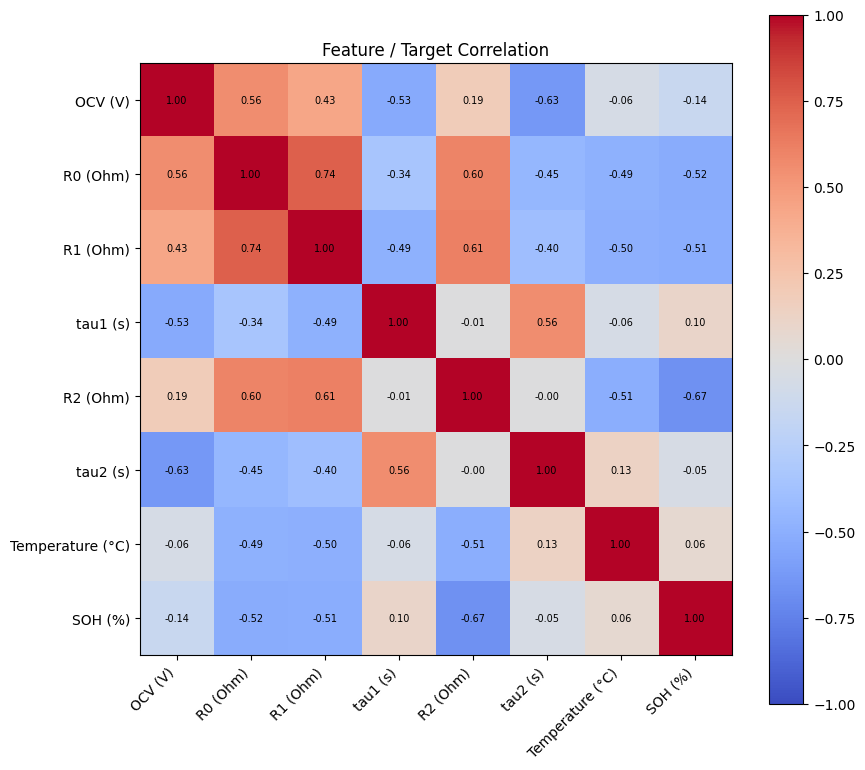

In [7]:
corr = data[FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im); plt.title("Feature / Target Correlation"); plt.tight_layout(); plt.show()

In [8]:
def evaluate(y_true, y_pred, name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)); mae = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred); mape = np.mean(np.abs((y_true-y_pred)/y_true))*100
    print(f"[{name:20s}] RMSE={rmse:6.3f}  MAE={mae:6.3f}  R2={r2:7.4f}  MAPE={mape:5.2f}%")
    return dict(rmse=rmse, mae=mae, r2=r2, mape=mape)

results = {}

## 4. GBDT 基线（全量数据，sklearn，已验证可跑）

`HistGradientBoostingRegressor` 直方图加速，几万行秒级完成、用满全部数据。
可无缝换成 XGBoost / LightGBM（注释里给了）。

In [9]:
# gb = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
#                                    max_depth=None, random_state=RANDOM_SEED)
# gb.fit(X_train_s, y_train)
# results["HistGBDT"] = evaluate(y_test, gb.predict(X_test_s), "HistGBDT")

# 可选: XGBoost / LightGBM (需 pip install)
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=5,
                   subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_SEED)
xgb.fit(X_train_s, y_train); results["XGBoost"] = evaluate(y_test, xgb.predict(X_test_s), "XGBoost")

[XGBoost             ] RMSE= 1.781  MAE= 1.268  R2= 0.9118  MAPE= 1.57%


### 4.1 置换重要性（类似 ARD 的特征相关性，基于 XGBoost）

在测试集上，逐个打乱某特征、看 R² 掉多少 → 掉得越多越重要。这是**基于 XGBoost 学到的依赖关系**，
不代表 MLP 学到的东西——MLP 专属的置换重要性见第 6.1 节，两者要分别看，避免混淆
"数据本身的可预测性"和"MLP 有没有学好"。

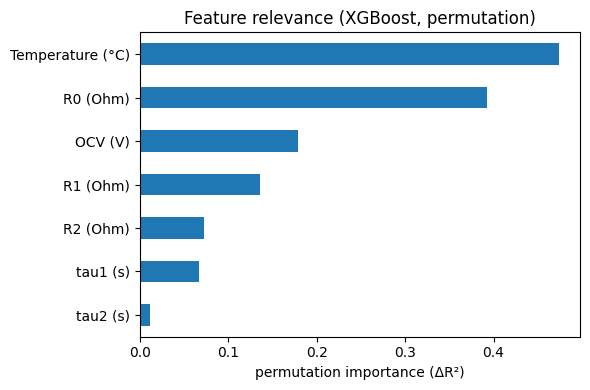

Temperature (°C)    0.4741
R0 (Ohm)            0.3929
OCV (V)             0.1783
R1 (Ohm)            0.1359
R2 (Ohm)            0.0725
tau1 (s)            0.0666
tau2 (s)            0.0116


In [10]:
perm = permutation_importance(xgb, X_test_s, y_test, n_repeats=10,
                              random_state=RANDOM_SEED, scoring="r2")
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
imp.plot(kind="barh"); plt.xlabel("permutation importance (ΔR²)")
plt.title("Feature relevance (XGBoost, permutation)"); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(4).to_string())

## 5. MLP 深度集成（迁移主力，全量数据）

网络拆成 **特征提取器 `feature`** + **回归头 `head`**（迁移时冻结 `feature`、只重训 `head`）。
训练 K 个不同随机种子的模型：**预测 = K 个输出的均值**，**不确定度 = K 个输出的标准差**。

相比最初版本的改动：
- `batch_size` 256→4096 + `ReduceLROnPlateau` 调度器，解决 CPU 上训练根本跑不完的问题；
- `hidden=(128,64,32)`（原 `(256,128,64)`）+ `dropout=0.25`（原 0.1）+ `weight_decay=3e-4`（原 1e-4），
  专门缓解"train R² 很高、test R² 跟不上"的过拟合；
- `BatchNorm` + `GELU` 替换纯 `ReLU`，训练更稳定；
- 记录每个 epoch 的 train/val loss，训练完可以直接画收敛曲线自查。

> 需 `pip install torch`。

In [11]:
y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))
yt = y_scaler.transform(y_train.reshape(-1, 1)).ravel()
yv = y_scaler.transform(y_val.reshape(-1, 1)).ravel()

def to_loader(Xs, ys, bs=4096, shuffle=False):
    ds = TensorDataset(torch.tensor(Xs, dtype=torch.float32),
                       torch.tensor(ys, dtype=torch.float32).view(-1, 1))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

class SOHNet(nn.Module):
    def __init__(self, in_dim=len(FEATURES), hidden=(128, 64, 32), p_drop=0.25):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(in_dim, hidden[0]), nn.BatchNorm1d(hidden[0]), nn.GELU(), nn.Dropout(p_drop),
            nn.Linear(hidden[0], hidden[1]), nn.BatchNorm1d(hidden[1]), nn.GELU(), nn.Dropout(p_drop),
            nn.Linear(hidden[1], hidden[2]), nn.BatchNorm1d(hidden[2]), nn.GELU())
        self.head = nn.Linear(hidden[2], 1)
        
    def forward(self, x): 
        return self.head(self.feature(x))

def train_one(seed, epochs=80, lr=2e-3, weight_decay=3e-4, patience=15,
              hidden=(128, 64, 32), p_drop=0.25,
              init_state=None, only_head=False, verbose=True):
    torch.manual_seed(seed)
    model = SOHNet(in_dim=len(FEATURES), hidden=hidden, p_drop=p_drop).to(device)
    if init_state is not None:
        model.load_state_dict(init_state)
    if only_head:
        for p in model.feature.parameters(): p.requires_grad = False
    params = model.head.parameters() if only_head else model.parameters()
    opt = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    loss_fn = nn.MSELoss()
    tl = to_loader(X_train_s, yt, shuffle=True); vl = to_loader(X_val_s, yv)
    best, best_state, wait = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}
    for ep in range(epochs):
        model.train(); tr_loss = 0.0
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= len(tl.dataset)
        model.eval(); v = 0.0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(device), yb.to(device)
                v += loss_fn(model(xb), yb).item() * len(xb)
        v /= len(vl.dataset)
        sched.step(v)
        history["train_loss"].append(tr_loss); history["val_loss"].append(v)
        if verbose and ep % 5 == 0:
            print(f"  seed={seed} epoch={ep:3d} train_loss={tr_loss:.4f} val_loss={v:.4f} "
                  f"lr={opt.param_groups[0]['lr']:.2e}")
        if v < best - 1e-6:
            best, wait = v, 0
            best_state = {k: val.detach().cpu().clone() for k, val in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state)
    model.history = history
    return model

print("SOHNet 与训练函数已就绪")


SOHNet 与训练函数已就绪


  seed=42 epoch=  0 train_loss=0.1344 val_loss=0.0526 lr=2.00e-03
  seed=42 epoch=  5 train_loss=0.0403 val_loss=0.0351 lr=2.00e-03
  seed=42 epoch= 10 train_loss=0.0342 val_loss=0.0348 lr=2.00e-03
  seed=42 epoch= 15 train_loss=0.0313 val_loss=0.0440 lr=1.00e-03
  seed=42 epoch= 20 train_loss=0.0298 val_loss=0.0480 lr=5.00e-04
  seed=2024 epoch=  0 train_loss=0.1343 val_loss=0.0461 lr=2.00e-03
  seed=2024 epoch=  5 train_loss=0.0391 val_loss=0.0399 lr=2.00e-03
  seed=2024 epoch= 10 train_loss=0.0326 val_loss=0.0384 lr=1.00e-03
  seed=2024 epoch= 15 train_loss=0.0316 val_loss=0.0419 lr=5.00e-04
  seed=9999 epoch=  0 train_loss=0.1329 val_loss=0.0516 lr=2.00e-03
  seed=9999 epoch=  5 train_loss=0.0384 val_loss=0.0503 lr=2.00e-03
  seed=9999 epoch= 10 train_loss=0.0327 val_loss=0.0434 lr=2.00e-03
  seed=9999 epoch= 15 train_loss=0.0303 val_loss=0.0464 lr=1.00e-03
  seed=9999 epoch= 20 train_loss=0.0287 val_loss=0.0516 lr=5.00e-04
已训练 3 个 MLP 组成集成
[MLP_ensemble(train) ] RMSE= 1.528  MAE= 

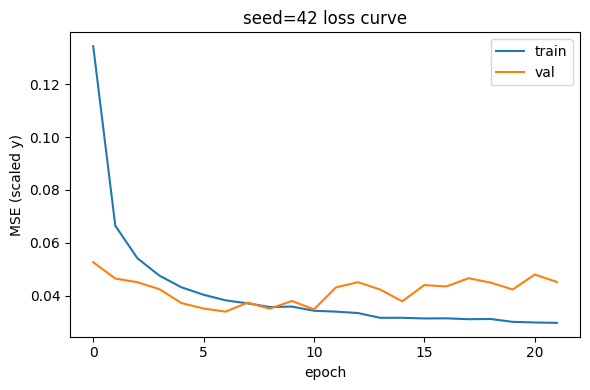

In [12]:
SEEDS = [42, 2024, 9999]
ensemble = [train_one(seed=s, hidden=(128, 64, 32), p_drop=0.25, weight_decay=3e-4) for s in SEEDS]
print(f"已训练 {len(SEEDS)} 个 MLP 组成集成")

def ensemble_predict(models, Xs):
    preds = []
    for m in models:
        m.eval()
        with torch.no_grad():
            p = m(torch.tensor(Xs, dtype=torch.float32).to(device)).cpu().numpy().ravel()
        preds.append(y_scaler.inverse_transform(p.reshape(-1, 1)).ravel())
    P = np.stack(preds)               # (K, N)
    return P.mean(0), P.std(0)        # 均值 = 预测, 标准差 = 不确定度

# 训练集诊断：train R2 低=欠拟合，train 高但 test 低=过拟合
mu_train, _ = ensemble_predict(ensemble, X_train_s)
results["MLP_ensemble_TRAIN"] = evaluate(y_train, mu_train, "MLP_ensemble(train)")

mu, std = ensemble_predict(ensemble, X_test_s)
results["MLP_ensemble"] = evaluate(y_test, mu, "MLP_ensemble")
print(f"集成平均不确定度 = {std.mean():.3f} SOH%")

# 第一个成员的 loss 曲线，看是否真的收敛了（train/val 应同步下降后趋于平稳）
plt.plot(ensemble[0].history["train_loss"], label="train")
plt.plot(ensemble[0].history["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE (scaled y)"); plt.legend()
plt.title(f"seed={SEEDS[0]} loss curve"); plt.tight_layout(); plt.show()

[Test                ] RMSE= 1.691  MAE= 1.121  R2= 0.9205  MAPE= 1.34%


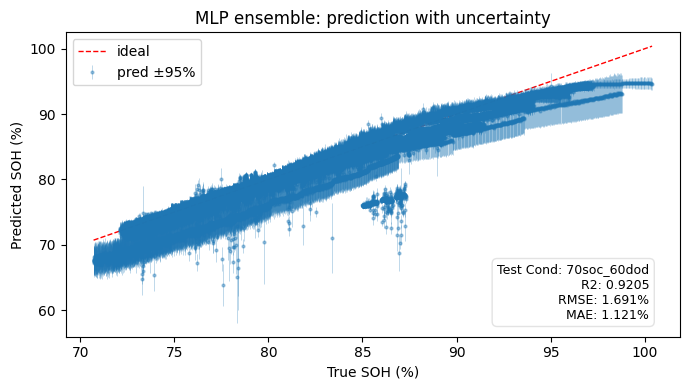

In [13]:
# 1. 直接调用你定义好的评估函数（同时也会触发内部的 print 打印输出）
res = evaluate(y_test, mu, name="Test")

# 2. 提取工况和指标，组合成右下角的文本
cond_str = ", ".join(TARGET_TEST_CONDITIONS) if'TARGET_TEST_CONDITIONS' in locals() else "Custom"
info_text = (
    f"Test Cond: {cond_str}\n"
    f"R2: {res['r2']:.4f}\n"
    f"RMSE: {res['rmse']:.3f}%\n"
    f"MAE: {res['mae']:.3f}%"
)

# 3. 绘图
idx = np.argsort(y_test)
plt.figure(figsize=(7, 4))
plt.plot(y_test[idx], y_test[idx], "r--", lw=1, label="ideal")
plt.errorbar(y_test[idx], mu[idx], yerr=1.96 * std[idx], fmt=".", ms=4,
             alpha=0.4, elinewidth=0.5, label="pred ±95%")
plt.xlabel("True SOH (%)"); plt.ylabel("Predicted SOH (%)")
plt.title("MLP ensemble: prediction with uncertainty")

# 图例放左上角，防止和右下角文本重叠
plt.legend(loc="upper left")

# 在右下角添加精简信息框
plt.gca().text(
    0.95, 0.05, info_text, 
    transform=plt.gca().transAxes, 
    ha="right", va="bottom", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8, edgecolor="gainsboro")
)

plt.tight_layout(); plt.show()


## 6. 诊断补充

### 6.1 MLP 专属置换重要性

第 4.1 节的置换重要性是基于 XGBoost 算的，这里单独对 MLP 集成算一次，两者对照看，
才能确认 MLP 是不是真的学到了合理的特征依赖（尤其关注 `d_*` 变化量特征是否排到前面——
如果是，说明模型学的是"衰减了多少"而不是"记住电池身份"）。

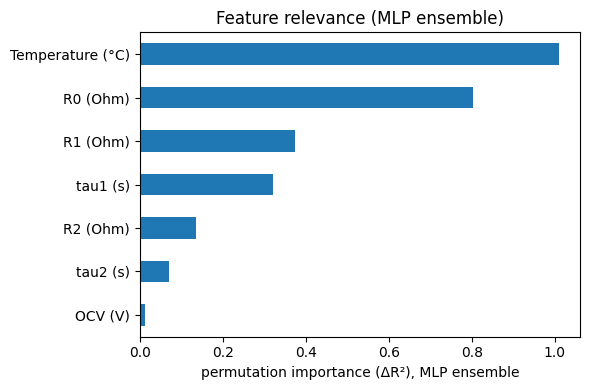

Temperature (°C)    1.0100
R0 (Ohm)            0.8035
R1 (Ohm)            0.3735
tau1 (s)            0.3217
R2 (Ohm)            0.1360
tau2 (s)            0.0712
OCV (V)             0.0118


In [14]:
def mlp_permutation_importance(models, X, y, n_repeats=10, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    base_mu, _ = ensemble_predict(models, X)
    base_r2 = r2_score(y, base_mu)
    importances = np.zeros((n_repeats, X.shape[1]))
    for r in range(n_repeats):
        for j in range(X.shape[1]):
            Xp = X.copy()
            rng.shuffle(Xp[:, j])
            mu_p, _ = ensemble_predict(models, Xp)
            importances[r, j] = base_r2 - r2_score(y, mu_p)
    return pd.Series(importances.mean(0), index=FEATURES).sort_values()

imp_mlp = mlp_permutation_importance(ensemble, X_test_s, y_test)
imp_mlp.plot(kind="barh"); plt.xlabel("permutation importance (ΔR²), MLP ensemble")
plt.title("Feature relevance (MLP ensemble)"); plt.tight_layout(); plt.show()
print(imp_mlp.sort_values(ascending=False).round(4).to_string())

### 6.2 关键特征的噪声敏感度检查

如果置换重要性显示模型对某个特征（例如 `d_R0 (Ohm)`）依赖过重，就值得检查一下：
给这个特征加不同强度的高斯噪声，看 test R² 掉多少。如果小幅噪声就让 R² 明显下滑，
说明模型"押宝"押得有点重，对该特征的测量误差比较敏感，可以考虑训练时对它做数据增强
（随机加小噪声），逼模型多用一点次要信号，泛化会更稳。

In [15]:
# 给 R0 加不同强度的高斯噪声，评估对测量误差的敏感度
target_col = "R0 (Ohm)"
col_idx = FEATURES.index(target_col)
noise_std = X_test_s[:, col_idx].std()
for noise_level in [0.0, 0.1, 0.3, 0.5, 1.0]:
    Xn = X_test_s.copy()
    Xn[:, col_idx] += np.random.default_rng(0).normal(0, noise_level * noise_std, size=len(Xn))
    mu_n, _ = ensemble_predict(ensemble, Xn)
    print(f"noise={noise_level:.1f}x std on {target_col} -> test R2={r2_score(y_test, mu_n):.4f}")


noise=0.0x std on R0 (Ohm) -> test R2=0.9205
noise=0.1x std on R0 (Ohm) -> test R2=0.9169
noise=0.3x std on R0 (Ohm) -> test R2=0.8878
noise=0.5x std on R0 (Ohm) -> test R2=0.8265
noise=1.0x std on R0 (Ohm) -> test R2=0.5054


### 6.3 定位误差最大的样本：按电池 vs 按 SOH 区间

预测散点图上如果出现"炸开"的离群点，需要判断这是**少数几块电池数据有问题**，
还是**某个 SOH 区间对所有电池来说都更难预测**。两种情况的应对完全不同：前者该清洗/复核数据，
后者该做样本加权或补充能区分老化路径的特征。

注意：**只看均值容易被样本量大的区间"稀释"、掩盖局部离群点**——同时看"大误差样本占比"和
"95 分位误差"，比单看均值更能反映真实的局部失败情况。

In [16]:
resid = np.abs(y_test - mu)

# 1) 严格 top-200，看真正误差最大的点是不是集中在少数电池上
worst200 = np.argsort(-resid)[:200]
print("Top-200 最差样本的电池分布：")
worst_cell_counts = data.iloc[test_idx[worst200]]["cell_id"].value_counts()

print(worst_cell_counts.head(10))

flagged_cells = set(worst_cell_counts.head(5).index)
print(f"\n✅ 动态提取的问题电池集合 (Top 5): {flagged_cells}")

# 2) 按 SOH 分桶：均值 + 大误差样本占比 + 95 分位误差
soh_bins = pd.cut(y_test, bins=[50, 60, 70, 80, 90, 100])
df_r = pd.DataFrame({"resid": resid, "bin": soh_bins})

print("\n按 SOH 区间统计的平均绝对误差：")
print(df_r.groupby("bin")["resid"].agg(["mean", "count"]))

big_miss = df_r.assign(big=lambda d: d["resid"] > 5).groupby("bin")["big"].agg(["sum", "mean", "count"])
big_miss.columns = ["大误差样本数(>5%)", "占该区间比例", "该区间总样本数"]
print("\n大误差样本占比（比均值更能反映局部离群，不被大样本量区间稀释）：")
print(big_miss)

p95 = df_r.groupby("bin")["resid"].quantile(0.95)
print("\n各区间 95 分位误差：")
print(p95)

Top-200 最差样本的电池分布：
cell_id
VTC6_078_25grad_70SOC_60DOD    93
VTC6_047_25grad_70SOC_60DOD    68
VTC6_007_25grad_70SOC_60DOD    32
VTC6_188_35grad_70SOC_60DOD     3
VTC6_003_25grad_70SOC_60DOD     2
VTC6_055_35grad_70SOC_60DOD     1
VTC6_178_35grad_70SOC_60DOD     1
Name: count, dtype: int64

✅ 动态提取的问题电池集合 (Top 5): {'VTC6_188_35grad_70SOC_60DOD', 'VTC6_078_25grad_70SOC_60DOD', 'VTC6_007_25grad_70SOC_60DOD', 'VTC6_047_25grad_70SOC_60DOD', 'VTC6_003_25grad_70SOC_60DOD'}

按 SOH 区间统计的平均绝对误差：
               mean  count
bin                       
(70, 80]   0.749940  27913
(80, 90]   1.314132  27671
(90, 100]  1.800000   7362

大误差样本占比（比均值更能反映局部离群，不被大样本量区间稀释）：
           大误差样本数(>5%)    占该区间比例  该区间总样本数
bin                                      
(70, 80]            58  0.002078    27913
(80, 90]           625  0.022587    27671
(90, 100]           59  0.008014     7362

各区间 95 分位误差：
bin
(70, 80]     3.630495
(80, 90]     3.463463
(90, 100]    3.465505
Name: resid, dtype: float64


### 6.4 GroupKFold 5 折交叉验证：确认结果不是单次切分的运气

单次随机切分下，测试集只有几十块电池，R² 的波动可能不小。这里用 5 折 `GroupKFold`
（保证同一块电池不会同时出现在训练/测试里）重新训练评估，看结果是否稳定，
更贴近模型真实的泛化能力——**以这个 5 折平均值作为最终汇报的指标，而不是单次切分的结果**。

In [17]:
from sklearn.model_selection import KFold  # 切换为标准的随机 KFold

# ==================== 1. 锁死指定测试集，提取剩余数据作为训练-验证池 (TrainVal) ====================
# 基于你之前的掩码，提取训练池与隔离测试集
X_tv = X[trainval_mask]
y_tv = y[trainval_mask]

X_test = X[test_mask]
y_test = y[test_mask]

# 初始化标准的随机 5 折交叉验证（打乱行顺序）
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = []
all_test_preds = []  # 收集 5 个折模型对【隔离测试集】的预测

print(f"🚀 开始在训练池（共 {len(X_tv)} 条样本）上进行随机 5 折交叉验证 (KFold)...")
print(f"🔒 {len(test_cells)} 块电池，共 {len(X_test)} 条样本）已完全锁死，全程不参与分折与训练。\n")

# ==================== 2. 随机 5 折交叉验证 ====================
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_tv, y_tv)):
    # 仅基于当前 Fold 的训练数据 fit 缩放器，严格防止标化泄露
    xs = StandardScaler().fit(X_tv[tr_idx])
    ys = StandardScaler().fit(y_tv[tr_idx].reshape(-1, 1))
    
    Xtr_s = xs.transform(X_tv[tr_idx])
    Xval_s = xs.transform(X_tv[val_idx])  # 当前折随机抽出的验证行
    ytr_s = ys.transform(y_tv[tr_idx].reshape(-1, 1)).ravel()

    # 模型初始化与超参数配置
    torch.manual_seed(fold)
    m = SOHNet(in_dim=len(FEATURES), hidden=(128, 64, 32), p_drop=0.25).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=2e-3, weight_decay=3e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    tl = to_loader(Xtr_s, ytr_s, shuffle=True)

    # 训练循环
    for ep in range(40):
        m.train()
        ep_loss = 0.0
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = nn.functional.mse_loss(m(xb), yb)
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb)
        sched.step(ep_loss / len(tl.dataset))

    # ---- 内部验证阶段：在随机抽取的验证行上评估 ----
    m.eval()
    with torch.no_grad():
        val_pred_s = m(torch.tensor(Xval_s, dtype=torch.float32).to(device)).cpu().numpy().ravel()
    val_pred = ys.inverse_transform(val_pred_s.reshape(-1, 1)).ravel()

    val_r2 = r2_score(y_tv[val_idx], val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_tv[val_idx], val_pred))
    cv_results.append((val_r2, val_rmse))
    
    print(f"Fold {fold}: 内部随机验证 R2={val_r2:.4f} | RMSE={val_rmse:.3f} (验证样本数={len(val_idx)})")

    # ---- 盲测阶段：用当前折训练出的模型去预测【11 块隔离测试集】 ----
    X_test_s = xs.transform(X_test)
    with torch.no_grad():
        test_pred_s = m(torch.tensor(X_test_s, dtype=torch.float32).to(device)).cpu().numpy().ravel()
    test_pred = ys.inverse_transform(test_pred_s.reshape(-1, 1)).ravel()
    all_test_preds.append(test_pred)

# ==================== 3. 汇总与终极集成评估 ====================
# 3.1 内部随机 5 折评估
r2_arr = np.array([r for r, _ in cv_results])
rmse_arr = np.array([r for _, r in cv_results])
print(f"\n📊 随机 5 折内部验证汇总: 平均 R2 = {r2_arr.mean():.4f} ± {r2_arr.std():.4f} | 平均 RMSE = {rmse_arr.mean():.3f} ± {rmse_arr.std():.3f}")

# 3.2 终极测试：对 5 折模型的预测取平均，评估指定测试集
final_test_pred = np.mean(all_test_preds, axis=0)
test_r2 = r2_score(y_test, final_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, final_test_pred))

print("\n" + "="*60)
print(f"🎯 指定测试集 ({len(test_cells)} 块隔离电池) 终极集成预测结果:")
print(f"   测试集最终 R2   : {test_r2:.4f}")
print(f"   测试集最终 RMSE : {test_rmse:.3f} %")
print("="*60)

🚀 开始在训练池（共 692026 条样本）上进行随机 5 折交叉验证 (KFold)...
🔒 22 块电池，共 62956 条样本）已完全锁死，全程不参与分折与训练。

Fold 0: 内部随机验证 R2=0.9609 | RMSE=2.051 (验证样本数=138406)
Fold 1: 内部随机验证 R2=0.9471 | RMSE=2.377 (验证样本数=138405)
Fold 2: 内部随机验证 R2=0.9363 | RMSE=2.619 (验证样本数=138405)
Fold 3: 内部随机验证 R2=0.9467 | RMSE=2.391 (验证样本数=138405)
Fold 4: 内部随机验证 R2=0.9561 | RMSE=2.175 (验证样本数=138405)

📊 随机 5 折内部验证汇总: 平均 R2 = 0.9494 ± 0.0085 | 平均 RMSE = 2.323 ± 0.196

🎯 指定测试集 (22 块隔离电池) 终极集成预测结果:
   测试集最终 R2   : 0.8351
   测试集最终 RMSE : 2.436 %


In [18]:
gkf = GroupKFold(n_splits=5)
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
    te_cells = set(groups[te_idx])
    flagged = flagged_cells & te_cells
    print(f"fold {fold}: 包含问题电池 = {flagged if flagged else '无'}")


fold 0: 包含问题电池 = {'VTC6_007_25grad_70SOC_60DOD', 'VTC6_078_25grad_70SOC_60DOD'}
fold 1: 包含问题电池 = 无
fold 2: 包含问题电池 = 无
fold 3: 包含问题电池 = {'VTC6_188_35grad_70SOC_60DOD', 'VTC6_047_25grad_70SOC_60DOD', 'VTC6_003_25grad_70SOC_60DOD'}
fold 4: 包含问题电池 = 无


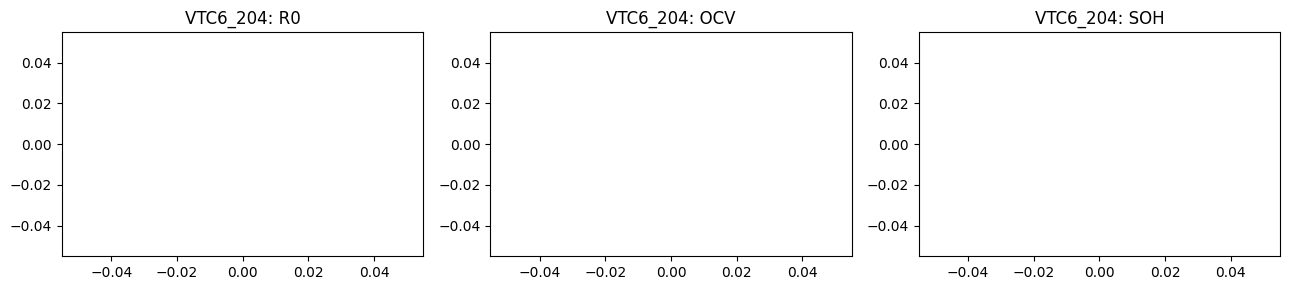

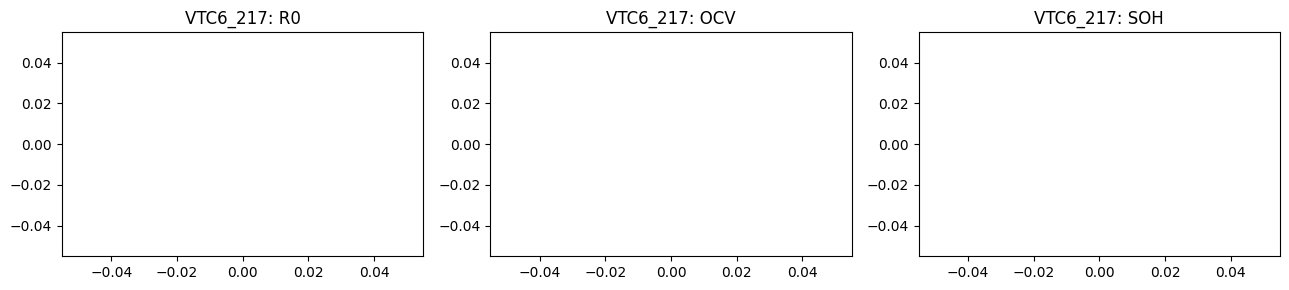

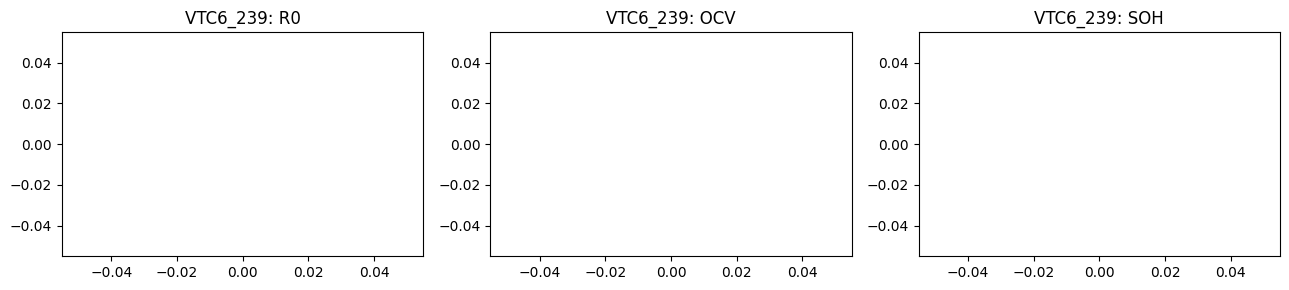

In [19]:
for cid in ["VTC6_204", "VTC6_217", "VTC6_239"]:
    sub = data[data["cell_id"] == cid].sort_values("file_order")
    fig, axes = plt.subplots(1, 3, figsize=(13, 3))
    axes[0].plot(sub["file_order"], sub["R0 (Ohm)"]); axes[0].set_title(f"{cid}: R0")
    axes[1].plot(sub["file_order"], sub["OCV (V)"]);  axes[1].set_title(f"{cid}: OCV")
    axes[2].plot(sub["file_order"], sub["SOH (%)"]);  axes[2].set_title(f"{cid}: SOH")
    plt.tight_layout(); plt.show()


## 所有电池趋势查看

In [20]:
# all_cell_ids = data["cell_id"].unique()
# print(f"总共有 {len(all_cell_ids)} 块电池")

# # 绘制所有电池的曲线（每个电池单独显示）
# for cid in all_cell_ids:
#     sub = data[data["cell_id"] == cid].sort_values("file_order")
    
#     fig, axes = plt.subplots(1, 3, figsize=(13, 3))
#     axes[0].plot(sub["file_order"], sub["R0 (Ohm)"])
#     axes[0].set_title(f"{cid}: R0")
#     axes[0].set_xlabel("File Order")
#     axes[0].set_ylabel("R0 (Ohm)")
    
#     axes[1].plot(sub["file_order"], sub["OCV (V)"])
#     axes[1].set_title(f"{cid}: OCV")
#     axes[1].set_xlabel("File Order")
#     axes[1].set_ylabel("OCV (V)")
    
#     axes[2].plot(sub["file_order"], sub["SOH (%)"])
#     axes[2].set_title(f"{cid}: SOH")
#     axes[2].set_xlabel("File Order")
#     axes[2].set_ylabel("SOH (%)")
    
#     plt.tight_layout()
#     plt.show()

## 7. 保存模型与预处理器

In [21]:
# import joblib
# joblib.dump({"features": FEATURES, "use_log_tau": USE_LOG_TAU, "log_tau_cols": LOG_TAU_COLS,
#              "x_scaler": x_scaler, "gbdt": xgb}, "nmc_gbdt.joblib")
# print("已保存 GBDT: nmc_gbdt.joblib")
# if HAS_TORCH:
#     torch.save({f"member_{i}": m.state_dict() for i, m in enumerate(ensemble)}, "nmc_mlp_ensemble.pt")
#     joblib.dump({"x_scaler": x_scaler, "y_scaler": y_scaler, "features": FEATURES,
#                  "use_log_tau": USE_LOG_TAU, "log_tau_cols": LOG_TAU_COLS}, "nmc_mlp_pre.joblib")
#     print("已保存 MLP 集成: nmc_mlp_ensemble.pt, nmc_mlp_pre.joblib")

## 8. 迁移到 LFP（拿到 LFP 数据后启用）

复用同一个文件夹加载器与分组划分。**逐个迁移集成中的每个成员**，迁移后仍是集成 → LFP 上也有不确定度。

| 策略 | 做法 | 适用 |
|---|---|---|
| A. 冻结特征提取器 | 加载 NMC 权重，冻结 `feature`，只训 `head` | LFP 数据较少，防过拟合 |
| B. 微调全部 | 加载 NMC 权重，用很小 lr（如 1e-4）微调整个网络 | LFP 数据稍多，上限更高 |

要点：LFP 量级不同 → **在 LFP 训练集上重新 fit `x_scaler`**；划分仍**按电池分组**；
LFP 也要按同样方式构造 `d_*` 相对特征（每块电池减自己的基准值）；
一定要有**从零训练的 LFP 集成**作对照，才能证明迁移带来收益。

In [22]:
# ============ LFP 迁移模板 (需 torch, 拿到 LFP 数据后启用) ============
# pre = joblib.load("nmc_mlp_pre.joblib")
# ck  = torch.load("nmc_mlp_ensemble.pt", map_location=device)
#
# lfp = load_all_batteries("path/to/LFP").dropna(subset=pre["features"] + [TARGET]).reset_index(drop=True)
# if pre["use_log_tau"]:
#     for c in pre["log_tau_cols"]: lfp[c] = np.log(lfp[c])
#
# Xl, yl, gl = (lfp[pre["features"]].values.astype(np.float32),
#               lfp[TARGET].values.astype(np.float32), lfp["cell_id"].values)
#
# tr, te = next(GroupShuffleSplit(1, test_size=0.25, random_state=RANDOM_SEED).split(Xl, yl, gl))
# lfp_xs = StandardScaler().fit(Xl[tr])                 # LFP 上重新 fit
# lfp_ys = StandardScaler().fit(yl[tr].reshape(-1,1))
# Xl_tr_s, Xl_te_s = lfp_xs.transform(Xl[tr]), lfp_xs.transform(Xl[te])
#
# def transfer_member(state, only_head=True, lr=1e-3):
#     model = SOHNet(in_dim=len(pre["features"]), hidden=(128,64,32), p_drop=0.25).to(device)
#     model.load_state_dict(state)                      # 载入 NMC 预训练权重
#     if only_head:                                     # 策略 A: 冻结特征提取器
#         for p in model.feature.parameters(): p.requires_grad = False
#     # ... 用 Xl_tr_s / lfp_ys 构造 loader, 训练 head (或 lr=1e-4 微调全部) ...
#     return model
#
# print("迁移模板: 拿到 LFP 数据后按注释启用（逐成员迁移，保留集成不确定度）。")


## 9. 批量实验：依次把每个工况当作测试集（Leave-One-Condition-Out）

把上面第 3 节的划分逻辑套进 `for` 循环，自动跑完全部单一工况：

| 步骤 | 做什么 |
|---|---|
| 9.1 | 把训练流程从全局变量里解耦成函数（原 `train_one` 依赖全局 `X_train_s`/`yt`，循环里没法复用） |
| 9.2 | `run_condition(cond)` = 划分 → 重新 fit 缩放器 → 训 K 个 MLP → 评估，一个工况一次实验 |
| 9.3 | 主循环，结果汇总成表并存 `loco_results.csv` |
| 9.4 | 各工况 R²/RMSE 柱状图 + 预测散点墙 |

**关键点**：每个工况实验都**重新 fit `x_scaler` / `y_scaler`**（因为训练集变了），
否则会有跨实验的信息泄露。

> ⚠️ 运行本节前，请先跑完第 1、2、3 节（`SOHNet` / `to_loader` 在第 5 节的 cell 里定义，也要先跑）。

In [23]:
# ============================================================
# 9.1 与全局变量解耦的训练函数（原 train_one 依赖全局 X_train_s/yt，无法在循环里复用）
# ============================================================

def train_one_for_split(Xtr_s, ytr_s, Xva_s, yva_s, seed=42, epochs=60, lr=2e-3,
                        weight_decay=3e-4, patience=10, hidden=(128, 64, 32),
                        p_drop=0.25, bs=4096, verbose=False):
    """在给定的一份 train/val 数据上训练单个 MLP，返回训练好的模型（带 history）。"""
    torch.manual_seed(seed)
    model = SOHNet(in_dim=Xtr_s.shape[1], hidden=hidden, p_drop=p_drop).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    loss_fn = nn.MSELoss()

    tl = to_loader(Xtr_s, ytr_s, bs=bs, shuffle=True)
    vl = to_loader(Xva_s, yva_s, bs=bs)

    best, best_state, wait = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}
    for ep in range(epochs):
        model.train(); tr_loss = 0.0
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= len(tl.dataset)

        model.eval(); v = 0.0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(device), yb.to(device)
                v += loss_fn(model(xb), yb).item() * len(xb)
        v /= len(vl.dataset)

        sched.step(v)
        history["train_loss"].append(tr_loss); history["val_loss"].append(v)
        if verbose and ep % 10 == 0:
            print(f"    seed={seed} ep={ep:3d} train={tr_loss:.4f} val={v:.4f}")

        if v < best - 1e-6:
            best, wait = v, 0
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.history = history
    return model


def predict_ensemble(models, Xs, y_scaler_local, bs=65536):
    """集成预测：返回 (均值, 跨模型标准差)，均已反标准化回 SOH(%)。"""
    preds = []
    for m in models:
        m.eval(); out = []
        with torch.no_grad():
            for i in range(0, len(Xs), bs):
                xb = torch.tensor(Xs[i:i + bs], dtype=torch.float32).to(device)
                out.append(m(xb).cpu().numpy().ravel())
        p = np.concatenate(out)
        preds.append(y_scaler_local.inverse_transform(p.reshape(-1, 1)).ravel())
    P = np.stack(preds)
    return P.mean(0), P.std(0)


def metrics_of(y_true, y_pred):
    return dict(
        rmse=float(np.sqrt(mean_squared_error(y_true, y_pred))),
        mae=float(mean_absolute_error(y_true, y_pred)),
        r2=float(r2_score(y_true, y_pred)),
        mape=float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
    )


# ============================================================
# 9.2 一个工况 = 一次完整实验
# ============================================================

def run_condition(test_cond, seeds=(42, 2024, 9999), n_donor=N_DONOR,
                  val_ratio=VAL_RATIO, epochs=60, patience=10, verbose=True):
    """把某个工况作为测试集跑一遍完整流程，返回指标 + 预测结果。"""
    sp = make_split([test_cond], n_donor=n_donor, val_ratio=val_ratio, verbose=verbose)
    tr, va, te = sp["train_idx"], sp["val_idx"], sp["test_idx"]

    # 每次实验都只在自己的训练集上重新 fit 缩放器
    xs = StandardScaler().fit(X[tr])
    ys = StandardScaler().fit(y[tr].reshape(-1, 1))
    Xtr_s, Xva_s, Xte_s = xs.transform(X[tr]), xs.transform(X[va]), xs.transform(X[te])
    ytr_s = ys.transform(y[tr].reshape(-1, 1)).ravel()
    yva_s = ys.transform(y[va].reshape(-1, 1)).ravel()

    models = [train_one_for_split(Xtr_s, ytr_s, Xva_s, yva_s, seed=s,
                                  epochs=epochs, patience=patience)
              for s in seeds]

    mu_tr, _      = predict_ensemble(models, Xtr_s, ys)
    mu_va, _      = predict_ensemble(models, Xva_s, ys)
    mu_te, std_te = predict_ensemble(models, Xte_s, ys)

    m_tr, m_va, m_te = (metrics_of(y[tr], mu_tr), metrics_of(y[va], mu_va),
                        metrics_of(y[te], mu_te))

    row = dict(condition=test_cond, n_donor=n_donor,
               n_test_cells=len(sp["test_cells"]), n_test_rows=len(te),
               n_train_rows=len(tr),
               test_r2=m_te["r2"], test_rmse=m_te["rmse"], test_mae=m_te["mae"],
               test_mape=m_te["mape"], mean_std=float(std_te.mean()),
               train_r2=m_tr["r2"], val_r2=m_va["r2"])

    if verbose:
        print(f"   ▶ train R2={m_tr['r2']:.4f} | val R2={m_va['r2']:.4f} | "
              f"TEST R2={m_te['r2']:.4f}  RMSE={m_te['rmse']:.3f}  MAE={m_te['mae']:.3f}")

    return dict(row=row, y_true=y[te], y_pred=mu_te, y_std=std_te,
                test_cells=sorted(sp["test_cells"]), cell_ids=groups[te],
                split=sp, models=models, scalers=(xs, ys))


print("✅ run_condition() 已就绪：run_condition('70soc_60dod') 即可单跑一个工况")

✅ run_condition() 已就绪：run_condition('70soc_60dod') 即可单跑一个工况


In [24]:
# ============================================================
# 9.3 主循环：依次把每个工况当作测试集，自动跑完全部实验
# ============================================================
import time

# ---- 循环配置（先用小配置试跑通，再放大）----
LOOP_CONDS   = ALL_CONDS          # 想只跑几个就写 ["25grad_70soc_60dod", "25grad_50soc_40dod"]
LOOP_SEEDS   = [42, 2024, 9999]   # 想快速试跑就改成 [42]（速度 ×3）
LOOP_EPOCHS  = 60
LOOP_PATIENCE = 10
DONOR_SETTINGS = [0,1]        # 改成 [0, 1] 可对比"零样本工况" vs "见过 1 块电池"
SAVE_PRED_CSV = False              # 是否把每个工况的逐样本预测存成 csv

all_rows, all_runs = [], {}
t_start = time.time()

for nd in DONOR_SETTINGS:
    for k, cond in enumerate(LOOP_CONDS, 1):
        print("\n" + "=" * 70)
        print(f"[{k}/{len(LOOP_CONDS)}] n_donor={nd} | 测试工况 = {cond}")
        print("=" * 70)
        t0 = time.time()
        try:
            out = run_condition(cond, seeds=LOOP_SEEDS, n_donor=nd,
                                epochs=LOOP_EPOCHS, patience=LOOP_PATIENCE, verbose=True)
        except Exception as e:
            print(f"❌ {cond} (n_donor={nd}) 运行失败：{e}")
            continue
        out["row"]["seconds"] = round(time.time() - t0, 1)
        all_rows.append(out["row"])
        all_runs[(nd, cond)] = out
        print(f"   ⏱ 耗时 {out['row']['seconds']:.1f}s")

        if SAVE_PRED_CSV:
            pd.DataFrame({
                "cell_id": out["cell_ids"],
                "y_true": out["y_true"],
                "y_pred": out["y_pred"],
                "y_std": out["y_std"],
                "abs_err": np.abs(out["y_true"] - out["y_pred"]),
            }).to_csv(f"pred_{cond}_donor{nd}.csv", index=False)

print(f"\n🏁 全部完成，总耗时 {(time.time() - t_start) / 60:.1f} 分钟")

# ---- 汇总表 ----
res_df = pd.DataFrame(all_rows)
if not res_df.empty:
    res_df = res_df.sort_values(["n_donor", "test_r2"], ascending=[True, False]).reset_index(drop=True)
    res_df.to_csv("loco_results.csv", index=False)

    show_cols = ["condition", "n_donor", "n_test_cells", "n_test_rows",
                 "train_r2", "val_r2", "test_r2", "test_rmse", "test_mae", "mean_std", "seconds"]
    print("\n📊 各工况留出测试结果（按 test R² 降序）：")
    print(res_df[show_cols].round(4).to_string(index=False))

    print("\n📈 全工况平均（宏平均，每个工况等权）：")
    print(res_df.groupby("n_donor")[["test_r2", "test_rmse", "test_mae"]]
          .agg(["mean", "std"]).round(4).to_string())
    print("\n💾 已保存：loco_results.csv")


[1/11] n_donor=0 | 测试工况 = 10soc_20dod
🎯 测试工况: ['10soc_20dod']
   ↳ 该工况捐给训练集的电池: 无 (n_donor=0)
   ↳ 该工况留作测试的电池 : 10 块
🔋 电池数  train/val/test = 152 / 38 / 10
📊 样本量  train/val/test = 559349 / 134681 / 60952
   ▶ train R2=0.9796 | val R2=0.9527 | TEST R2=0.8423  RMSE=4.741  MAE=3.713
   ⏱ 耗时 357.8s

[2/11] n_donor=0 | 测试工况 = 30soc_40dod
🎯 测试工况: ['30soc_40dod']
   ↳ 该工况捐给训练集的电池: 无 (n_donor=0)
   ↳ 该工况留作测试的电池 : 11 块
🔋 电池数  train/val/test = 151 / 38 / 11
📊 样本量  train/val/test = 550864 / 157352 / 46766
   ▶ train R2=0.9768 | val R2=0.9778 | TEST R2=0.9905  RMSE=1.022  MAE=0.752
   ⏱ 耗时 336.2s

[3/11] n_donor=0 | 测试工况 = 30soc_60dod
🎯 测试工况: ['30soc_60dod']
   ↳ 该工况捐给训练集的电池: 无 (n_donor=0)
   ↳ 该工况留作测试的电池 : 27 块
🔋 电池数  train/val/test = 138 / 35 / 27
📊 样本量  train/val/test = 538446 / 134292 / 82244
   ▶ train R2=0.9775 | val R2=0.9574 | TEST R2=0.9410  RMSE=2.764  MAE=1.587
   ⏱ 耗时 412.1s

[4/11] n_donor=0 | 测试工况 = 50soc_100dod
🎯 测试工况: ['50soc_100dod']
   ↳ 该工况捐给训练集的电池: 无 (n_donor=0)
   ↳ 该工况留作测试的电池

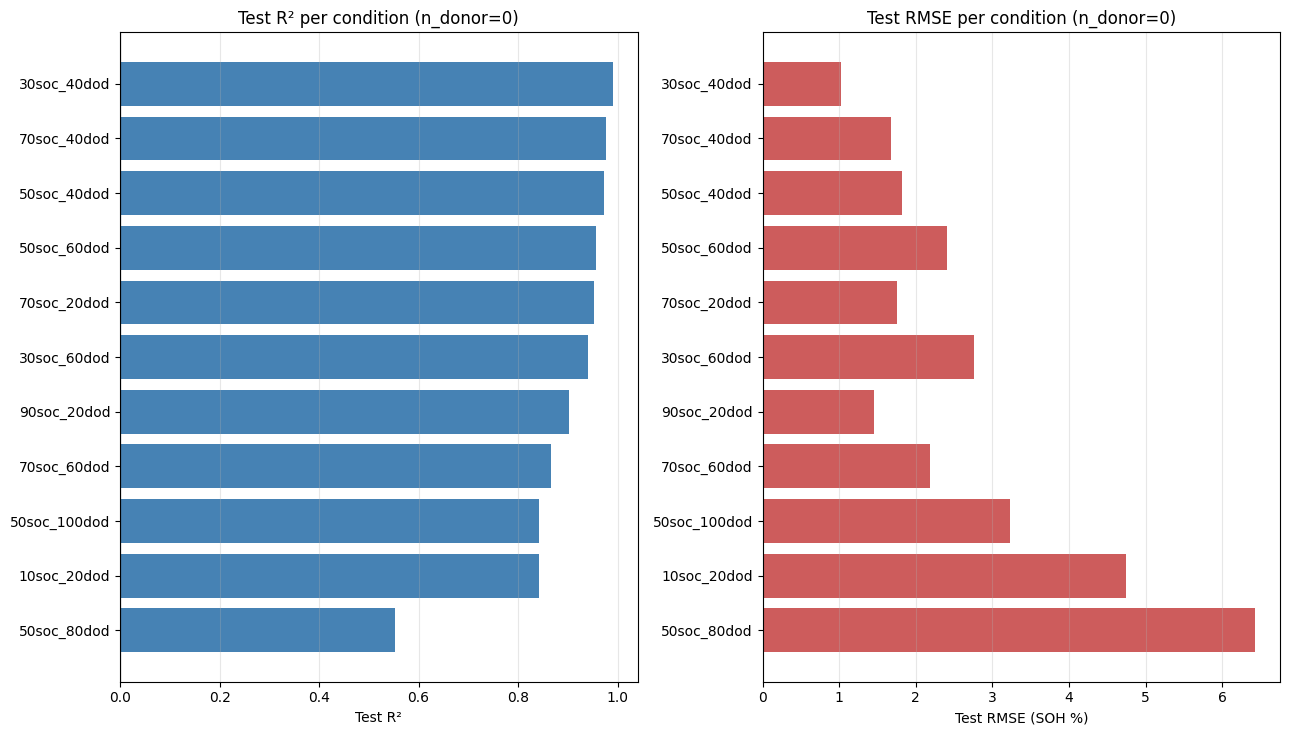

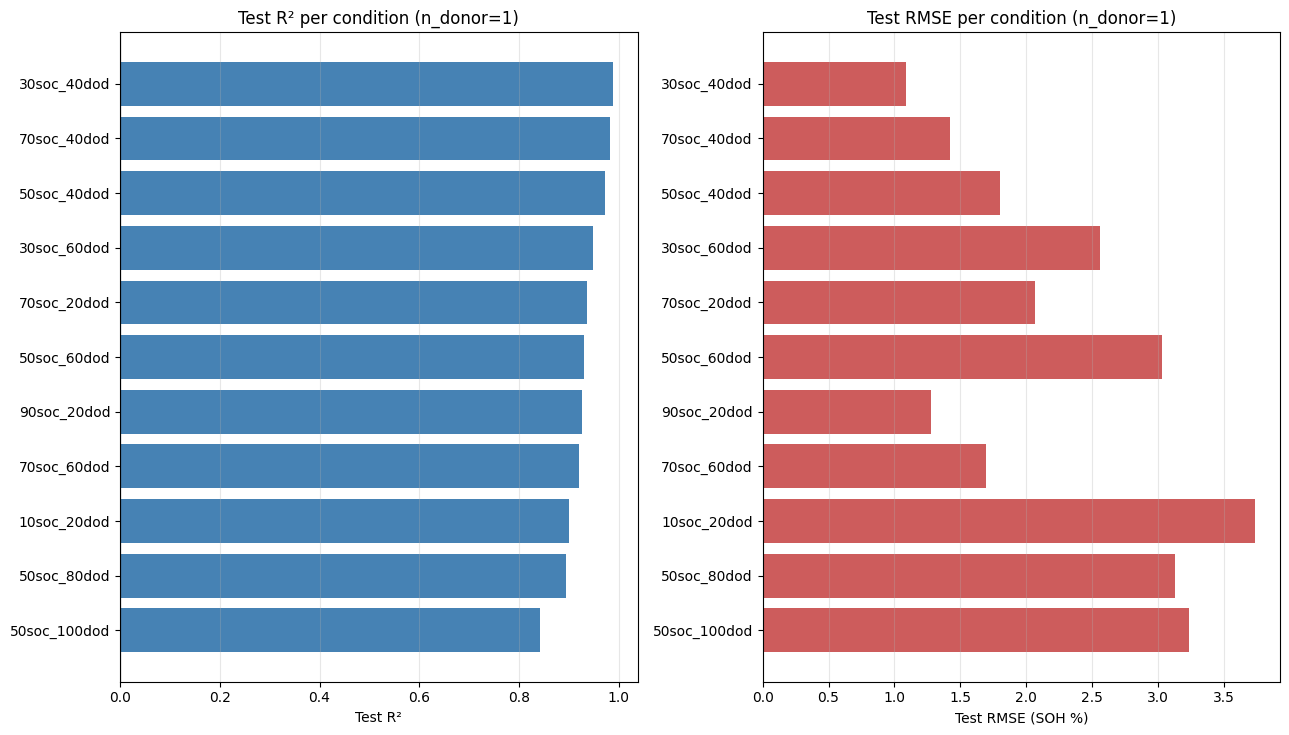

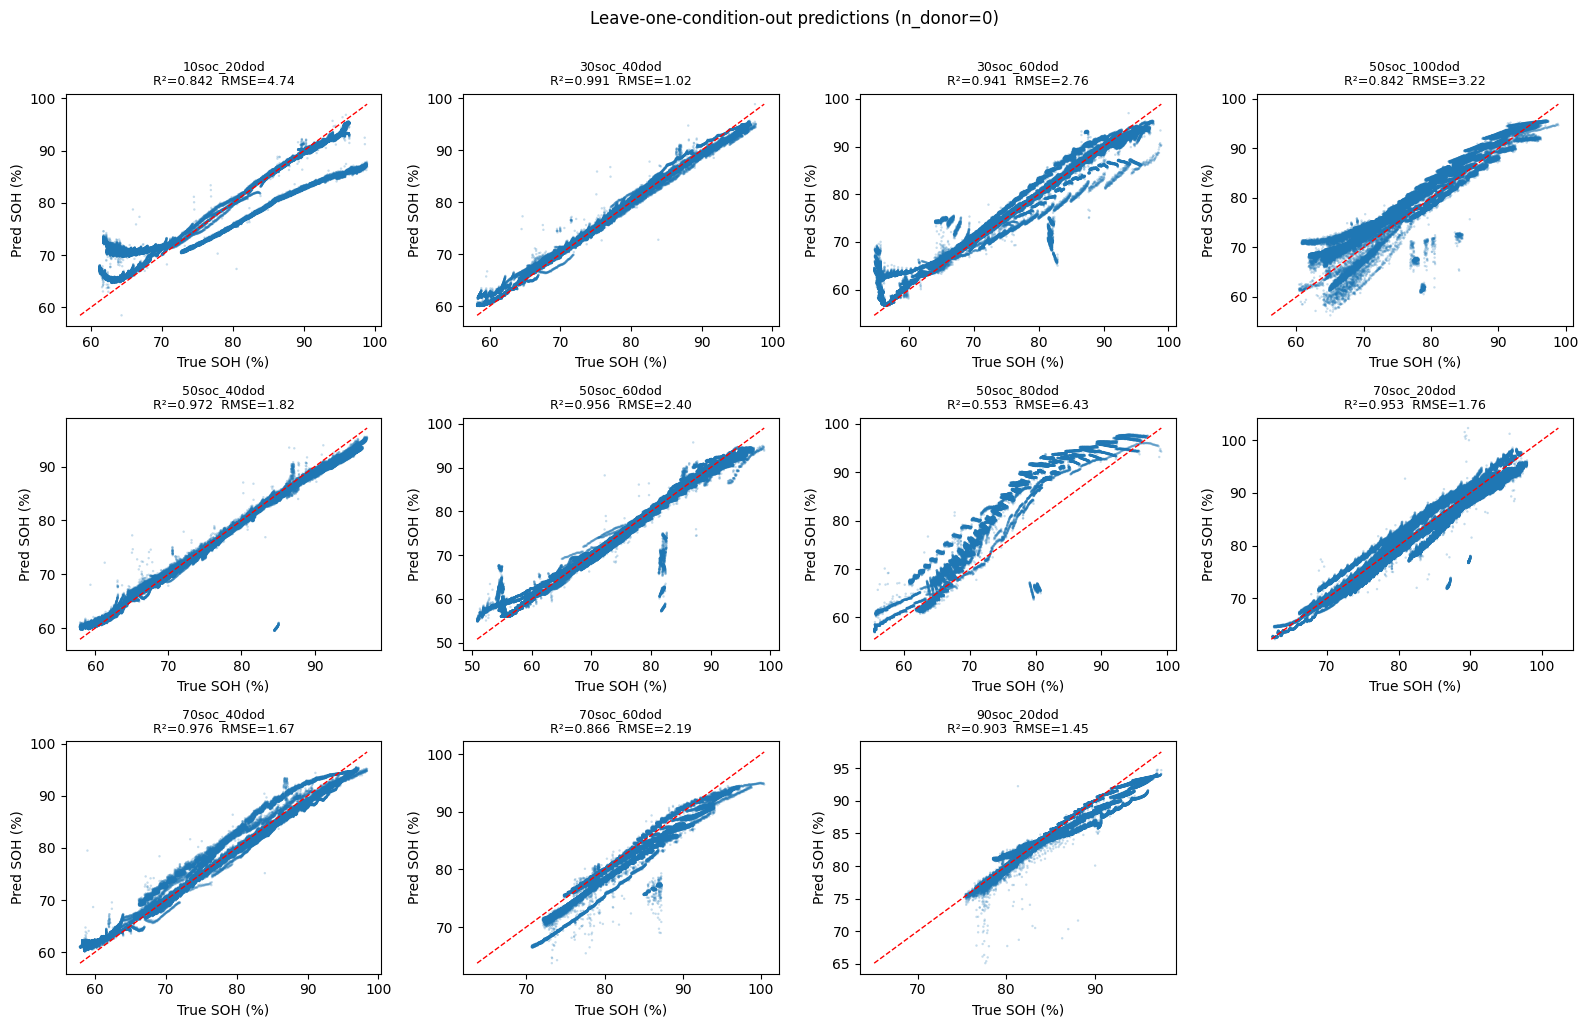

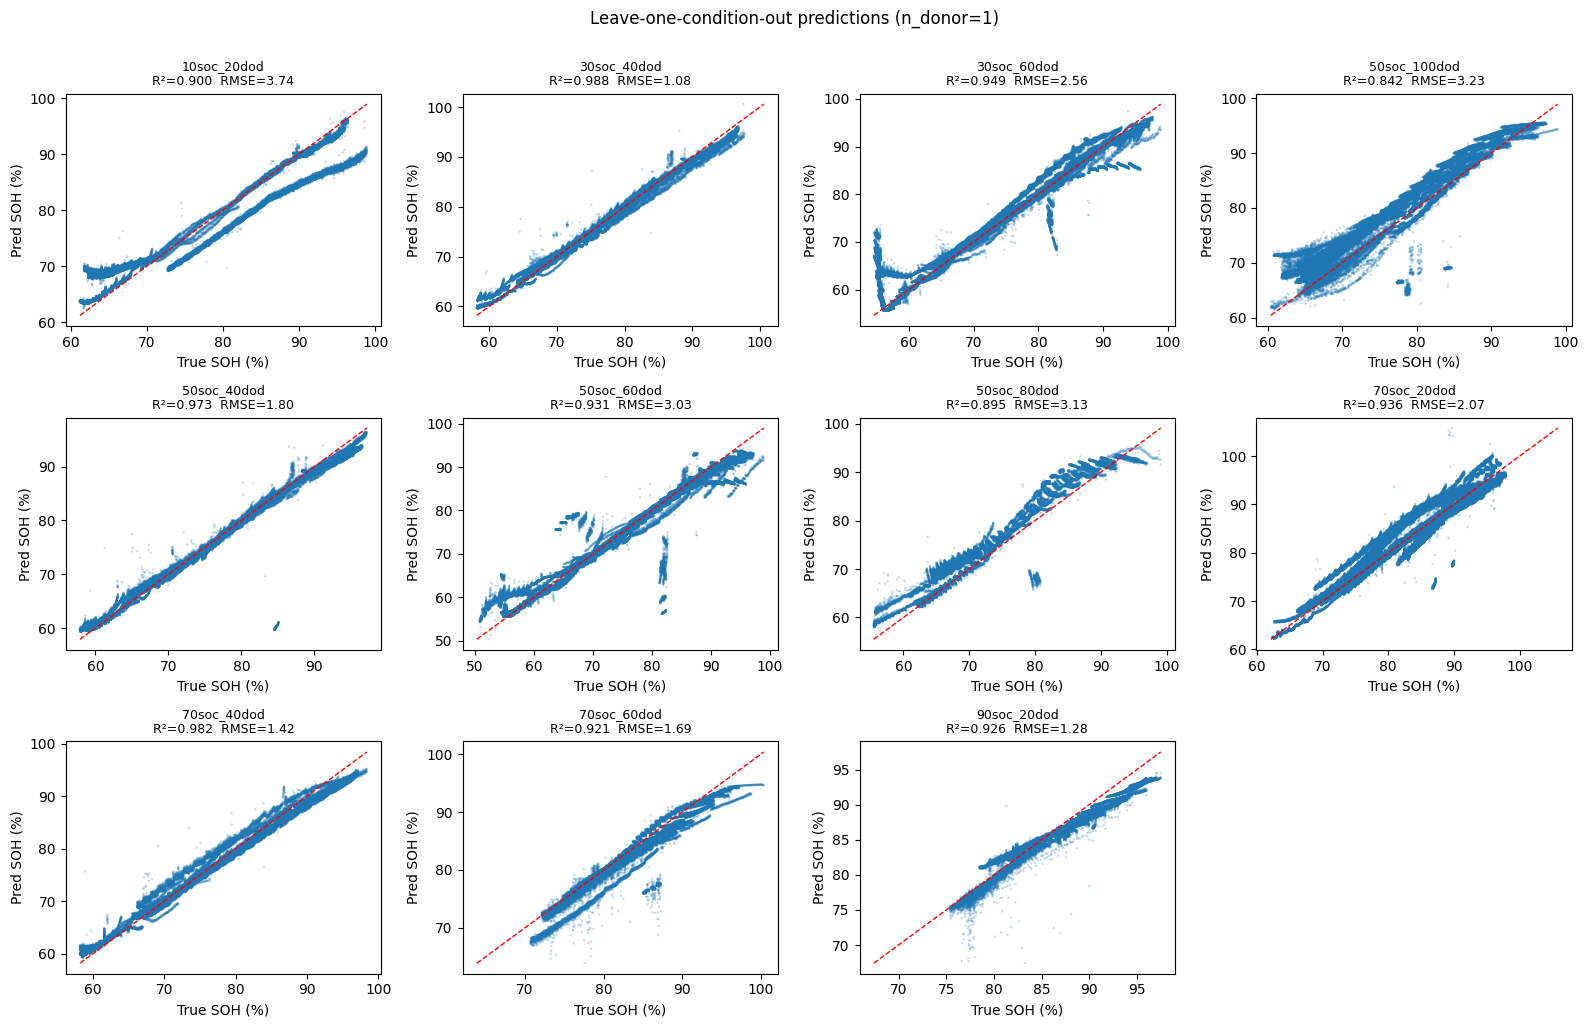


🔬 每个工况『训练集里放几块该工况电池』带来的 test R² 变化：
n_donor            0       1    gain
condition                           
10soc_20dod   0.8423  0.9000  0.0577
30soc_40dod   0.9905  0.9884 -0.0022
30soc_60dod   0.9410  0.9487  0.0076
50soc_100dod  0.8424  0.8423 -0.0001
50soc_40dod   0.9719  0.9732  0.0012
50soc_60dod   0.9559  0.9308 -0.0251
50soc_80dod   0.5525  0.8954  0.3428
70soc_20dod   0.9535  0.9356 -0.0178
70soc_40dod   0.9762  0.9821  0.0059
70soc_60dod   0.8659  0.9205  0.0546
90soc_20dod   0.9032  0.9263  0.0231


In [25]:
# ============================================================
# 9.4 结果可视化：每个工况的 R²/RMSE 柱状图 + 预测散点墙
# ============================================================

# ---- (1) 各工况指标柱状图 ----
for nd in sorted(res_df["n_donor"].unique()):
    sub = res_df[res_df["n_donor"] == nd].sort_values("test_r2")
    fig, axes = plt.subplots(1, 2, figsize=(13, 0.45 * len(sub) + 2.5))
    axes[0].barh(sub["condition"], sub["test_r2"], color="steelblue")
    axes[0].axvline(0, color="k", lw=0.8)
    axes[0].set_xlabel("Test R²"); axes[0].set_title(f"Test R² per condition (n_donor={nd})")
    axes[1].barh(sub["condition"], sub["test_rmse"], color="indianred")
    axes[1].set_xlabel("Test RMSE (SOH %)"); axes[1].set_title(f"Test RMSE per condition (n_donor={nd})")
    for ax in axes:
        ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.show()

# ---- (2) 预测散点墙：一个工况一张子图 ----
for nd in sorted(res_df["n_donor"].unique()):
    conds = [c for (d, c) in all_runs if d == nd]
    if not conds:
        continue
    ncol = 4
    nrow = int(np.ceil(len(conds) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.4 * nrow), squeeze=False)
    for ax, cond in zip(axes.ravel(), conds):
        out = all_runs[(nd, cond)]
        yt_, yp_ = out["y_true"], out["y_pred"]
        ax.scatter(yt_, yp_, s=3, alpha=0.25, edgecolors="none")
        lo, hi = float(min(yt_.min(), yp_.min())), float(max(yt_.max(), yp_.max()))
        ax.plot([lo, hi], [lo, hi], "r--", lw=1)
        r = out["row"]
        ax.set_title(f"{cond}\nR²={r['test_r2']:.3f}  RMSE={r['test_rmse']:.2f}", fontsize=9)
        ax.set_xlabel("True SOH (%)"); ax.set_ylabel("Pred SOH (%)")
    for ax in axes.ravel()[len(conds):]:
        ax.axis("off")
    fig.suptitle(f"Leave-one-condition-out predictions (n_donor={nd})", y=1.002)
    plt.tight_layout(); plt.show()

# ---- (3) 若跑了 n_donor=0 与 1 的对比，直接看增益 ----
if res_df["n_donor"].nunique() > 1:
    piv = res_df.pivot(index="condition", columns="n_donor", values="test_r2")
    piv["gain"] = piv[piv.columns.max()] - piv[piv.columns.min()]
    print("\n🔬 每个工况『训练集里放几块该工况电池』带来的 test R² 变化：")
    print(piv.round(4).to_string())